# Data Understanding




Data Iris terdiri dari 5 kolom:
* Sepal_length
* Sepal_width
* Petal_length
* Petal_width
* Species

Screenshoot Orange

![Irisi_Orange](image/orange2.png)

In [311]:
from statistics import variance
import csv
import psycopg
from math import sqrt
from itertools import count

from zmq import has

conn = psycopg.connect(
    host="localhost",
    dbname="pendat",
    user="postgres",
    password="rafif123",
    port = 5432
)

cur = conn.cursor()
cur.execute("SELECT * FROM data_iris")
potgress = cur.fetchall()

data = [list(row) for row in potgress]

nama_kolom = []
for i in cur.description:
    nama_kolom.append(i[0])

def read_csv(file_path):
    with open(file_path, mode='r') as file:
        csv_reader = csv.reader(file,delimiter=';')
        data = [row for row in csv_reader]
    return data


def missing(data,colom):
    count = 0
    for row in data:
        if row[colom] == '' or row[colom] is None:
            count += 1
    return count

def mean(data,colom):
    hasil = 0
    count = 0
    for row in data:
        hasil += float(row[colom])
        count += 1
    
    hasil /= count
    hasil = round(hasil,3)
    return hasil

def mode(data,colom):
    count = {}
    for row in data:
        nilai = row[colom]
        if nilai in count:
            count[nilai] += 1
        else:
            count[nilai] = 1
    
    hasil = 0
    value_awal = 0
    for key,value in count.items():
        if value > value_awal:
            value_awal = value
            hasil = key    
    return hasil 

def median(data,colom):
    nilai = len(data)
    sort = []
    for row in data:
        sort.append(float(row[colom]))
    sort.sort()

    if nilai % 2 == 0:
        median1 = sort[nilai // 2]  
        median2  = sort[nilai // 2 - 1]
        hasil = (median1 + median2) / 2
    else:
        hasil = sort[nilai // 2]
    hasil = round(hasil,3)
    return hasil

def dispersion(data,colom):
    hasil = 0
    rata_rata = mean(data,colom)
    for row in data:
        nilai = float(row[colom])
        selisih = nilai - rata_rata
        hasil += selisih ** 2
    variance = hasil / (len(data) - 1)
    std = sqrt(variance)
    return std

def max_value(data,colom):
    hasil = 0
    for row in data:
        nilai = float(row[colom])
        if nilai > hasil:
            hasil = nilai
    return hasil

def min_value(data,colom):
    hasil = float(data[1][colom])
    for row in data:
        nilai = float(row[colom])
        if nilai < hasil:
            hasil = nilai
    return hasil

def deviation(data, colom):
    hasil = 0
    rata_rata = mean(data, colom)

    for row in data:
        nilai = float(row[colom])
        selisih = nilai - rata_rata
        hasil += selisih ** 2

    hasil /= (len(data)-1)
    return hasil


def normalisasi(data, colom):
    hasil = []
    rata_rata = mean(data, colom)
    deviasi = deviation(data, colom)

    for row in data:
        nilai = float(row[colom])
        normal = (nilai - rata_rata) / sqrt(deviasi)
        hasil.append(round(normal,3))

    for i in range(len(data)):
        data[i][colom] = hasil[i]

    return data

def euclidean(data):   
    hasil = []  
    for row_i in data:
        jarak = []
        for row_j in data:
            total_kuadrat = 0
            for k in range(len(data[0]) - 1):
                total_kuadrat += (float(row_i[k]) - float(row_j[k])) ** 2
            jarak.append(round(sqrt(total_kuadrat),3))
        hasil.append(jarak)
    return hasil

def manhattan(data):     
    hasil = []
    for row_i in data:
        jarak = []
        for row_j in data:
            total_kuadrat = 0
            for k in range(len(data[0]) - 1):
                total_kuadrat += abs(float(row_i[k]) - float(row_j[k]))
            jarak.append(round(total_kuadrat,3))
        hasil.append(jarak)
    return hasil



In [312]:
import pandas as pd
df = pd.DataFrame(data, columns=nama_kolom)
pd.DataFrame(df[:10])

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## Feature statistics

![statistic](image/statistik.png)

In [313]:
for i in range(len(data[0]) - 1):
    print(f"Kolom {nama_kolom[i]} :")
    print(f"Missing {nama_kolom[i]} = {missing(data,i)}")
    print(f"Mean {nama_kolom[i]} = {mean(data,i)}")
    print(f"Median {nama_kolom[i]} = {median(data,i)}")
    print(f"Mode {nama_kolom[i]} = {mode(data,i)}")
    print(f"Std Dev {nama_kolom[i]} = {round(dispersion(data,i),3)}")
    print(f"Max {nama_kolom[i]} = {max_value(data,i)}")
    print(f"Min {nama_kolom[i]} = {min_value(data,i)}")
    print()

Kolom sepal_length :
Missing sepal_length = 0
Mean sepal_length = 5.843
Median sepal_length = 5.8
Mode sepal_length = 5
Std Dev sepal_length = 0.828
Max sepal_length = 7.9
Min sepal_length = 4.3

Kolom sepal_width :
Missing sepal_width = 0
Mean sepal_width = 3.054
Median sepal_width = 3.0
Mode sepal_width = 3
Std Dev sepal_width = 0.434
Max sepal_width = 4.4
Min sepal_width = 2.0

Kolom petal_length :
Missing petal_length = 0
Mean petal_length = 3.759
Median petal_length = 4.35
Mode petal_length = 1.5
Std Dev petal_length = 1.764
Max petal_length = 6.9
Min petal_length = 1.0

Kolom petal_width :
Missing petal_width = 0
Mean petal_width = 1.199
Median petal_width = 1.3
Mode petal_width = 0.2
Std Dev petal_width = 0.763
Max petal_width = 2.5
Min petal_width = 0.1



## Distribution

Distribution atau distribusi data digunakan untuk melihat bagaimana penyebaran nilai pada setiap atribut dalam dataset.
Dengan melihat distribusi, kita dapat memahami pola data, apakah data tersebar merata, condong ke satu sisi, atau memiliki pola tertentu.

### Menggunakan code python

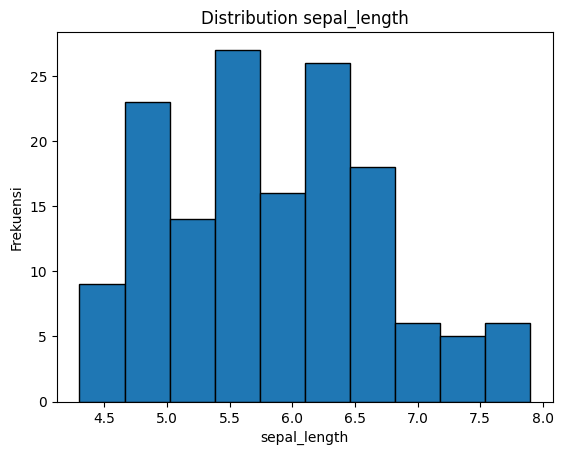

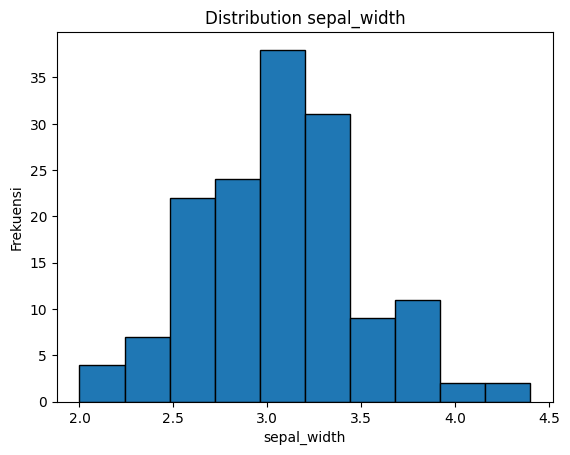

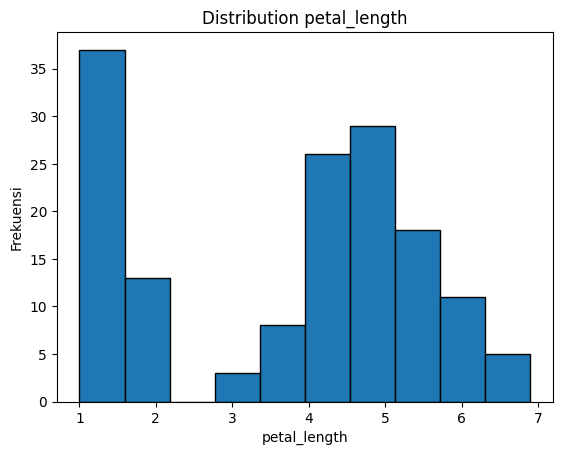

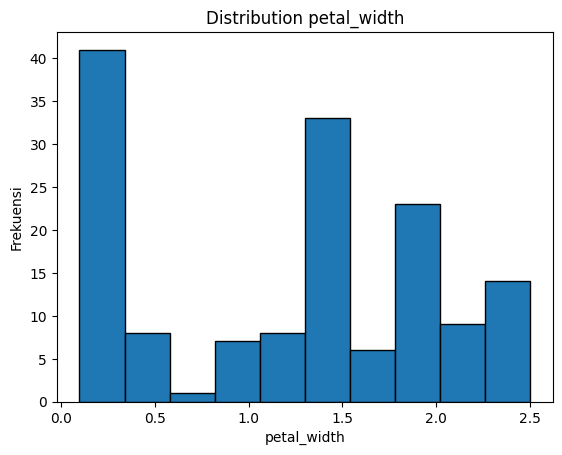

In [314]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("IRIS(2).csv", sep=';')
df.head()

kolom = df.columns[:-1]

for k in kolom:
    plt.figure()
    plt.hist(df[k], bins=10, edgecolor='black')
    plt.title(f"Distribution {k}")
    plt.xlabel(k)
    plt.ylabel("Frekuensi")
    plt.show()

### Menggunakan Orange Data Mining

### Sepal length
![Sepal length](image/sepal_length.png)

### Sepal width
![Sepal width](image/sepal_width.png)

### Petal length
![Petal length](image/petal_length.png)

### Petal width
![Petal width](image/petal_width.png)

## Distance



### Euclidean
Distance adalah ukuran jarak “lurus” antara dua titik dalam ruang berdimensi n. Secara matematis, Euclidean distance antara dua titik x=(x1,x2,…,xn) dan y=(y1,y2,…,yn) dinyatakan sebagai:

![rumus_euclidean](image/euclidean.png)

Metrik ini mencerminkan jarak geometris antar titik dalam ruang Euclidean dan memberikan representasi langsung dari seberapa jauh dua titik berada satu sama lain dalam ruang fitur. Keunggulan Euclidean distance adalah sederhana, intuitif, serta memiliki nilai yang mudah diinterpretasikan dalam ruang berdimensi rendah hingga menengah. Euclidean distance memiliki keterbatasan. Misalnya, pada dataset berdimensi tinggi atau data dengan skala yang sangat beragam antar fitur, Euclidean distance bisa memberikan hasil yang kurang representatif, karena metrik ini cenderung sensitif terhadap skala dan variansi fitur.

![Euclidean](image/eucli.png)

In [315]:
import pandas as pd

for i in range(len(data[0]) - 1):
    data = normalisasi(data, i)

data = data[:10]
pd.DataFrame(euclidean(data), columns=range(1,11))


,1,2,3,4,5,6,7,8,9,10
0,0.000,1.179,0.846,1.105,0.260,1.039,0.660,0.267,1.622,0.965
1,1.179,0.000,0.524,0.433,1.389,2.185,1.000,0.933,0.646,0.272
2,0.846,0.524,0.000,0.285,0.992,1.855,0.498,0.597,0.784,0.376
3,1.105,0.433,0.285,0.000,1.251,2.102,0.707,0.844,0.524,0.385
4,0.260,1.389,0.992,1.251,0.000,0.900,0.680,0.465,1.769,1.168
5,1.039,2.185,1.855,2.102,0.900,0.000,1.519,1.282,2.622,1.984
6,0.660,1.000,0.498,0.707,0.680,1.519,0.000,0.504,1.185,0.826
7,0.267,0.933,0.597,0.844,0.465,1.282,0.504,0.000,1.363,0.715
8,1.622,0.646,0.784,0.524,1.769,2.622,1.185,1.363,0.000,0.773
9,0.965,0.272,0.376,0.385,1.168,1.984,0.826,0.715,0.773,0.000


### Manhattan

Manhattan distance atau jarak Manhattan sering juga disebut Taxicab distance atau City Block distance. Manhattan distance adalah metrik ukur yang umumnya digunakan untuk menghitung jarak antara dua titik data dalam jalur seperti grid.
Jarak Manhattan dihitung sebagai jumlah dari perbedaan mutlak antara dua vektor. Adapun rumus dari Manhattan distance adalah:

![Rumus_manhattan](image/rumus_manhattan.png)

![manhattan](image/manhattan.png)

In [322]:
import pandas as pd

for i in range(len(data[0]) - 1):
    data = normalisasi(data, i)

data = data[:10]
pd.DataFrame(manhattan(data), columns=range(1,11))

,1,2,3,4,5,6,7,8,9,10
0,0.000,2.317,3.278,3.949,0.668,7.639,3.310,1.600,4.358,4.188
1,2.317,0.000,2.265,2.284,2.297,9.956,3.599,2.577,2.041,2.523
2,3.278,2.265,0.000,2.529,3.258,10.917,3.192,3.538,2.938,4.136
3,3.949,2.284,2.529,0.000,3.929,9.728,3.175,2.349,2.269,2.295
4,0.668,2.297,3.258,3.929,0.000,7.659,3.290,1.580,4.338,4.168
5,7.639,9.956,10.917,9.728,7.659,0.000,8.413,7.379,11.997,9.967
6,3.310,3.599,3.192,3.175,3.290,8.413,0.000,3.570,3.584,5.470
7,1.600,2.577,3.538,2.349,1.580,7.379,3.570,0.000,4.618,2.588
8,4.358,2.041,2.938,2.269,4.338,11.997,3.584,4.618,0.000,4.564
9,4.188,2.523,4.136,2.295,4.168,9.967,5.470,2.588,4.564,0.000


## Data Campuran 


In [317]:
import pandas as pd
data_cmp = pd.read_csv('data_campuran.csv', sep=';')
data_cmp = data_cmp[:20]

pd.DataFrame(data_cmp)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


### Euclidean Data Campuran

In [318]:
import pandas as pd
from math import sqrt

df = pd.read_csv('data_campuran.csv', sep=";")
df = df.drop('target', axis=1)
df = (df - df.min()) / (df.max() - df.min())
data_list = df.values.tolist()
data_list = data_list[:10]

def euclidean(data):
    hasil = []
    for i in range(len(data)):
        baris = []
        for j in range(len(data)):
            jumlah = 0
            for k in range(len(data[i])):
                jumlah += (data[i][k] - data[j][k]) ** 2
            baris.append(sqrt(jumlah))
        hasil.append(baris)
    return hasil

pd.DataFrame(euclidean(data_list))

,0,1,2,3,4,5,6,7,8,9
0,0.000000,1.909307,1.614959,0.417168,1.661978,1.436113,1.479297,1.318409,0.748058,1.387685
1,1.909307,0.000000,1.200413,1.896858,1.851934,1.924344,2.050359,1.237672,1.792363,1.328601
2,1.614959,1.200413,0.000000,1.534347,2.016084,1.717411,1.615692,0.925588,1.640204,1.048225
3,0.417168,1.896858,1.534347,0.000000,1.712832,1.416959,1.627732,1.264342,0.724190,1.474904
4,1.661978,1.851934,2.016084,1.712832,0.000000,1.412437,1.703606,1.948254,1.854652,1.847481
5,1.436113,1.924344,1.717411,1.416959,1.412437,0.000000,1.812789,1.593281,1.220025,1.560627
6,1.479297,2.050359,1.615692,1.627732,1.703606,1.812789,0.000000,1.865386,1.853523,1.585123
7,1.318409,1.237672,0.925588,1.264342,1.948254,1.593281,1.865386,0.000000,1.224114,0.708137
8,0.748058,1.792363,1.640204,0.724190,1.854652,1.220025,1.853523,1.224114,0.000000,1.357170
9,1.387685,1.328601,1.048225,1.474904,1.847481,1.560627,1.585123,0.708137,1.357170,0.000000
